# Setup

Install dependencies, clone the repo, and import required libraries and modules.

In [3]:
# Install dependencies
!pip install -q pillow


In [1]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 209 (delta 19), reused 9 (delta 5), pack-reused 171 (from 1)
Receiving objects: 100% (209/209), 19.05 MiB | 18.40 MiB/s, done.
Resolving deltas: 100% (107/107), done.


In [2]:
# Imports
import os
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm
from google.colab import files

# Metadata

Load the pre-processed Fakeddit metadata.

In [6]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [7]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_subset_blip2captions.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
image_df.head()


Loaded 225 clean samples.
Shape subset: (225, 5)


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,1,https://preview.redd.it/r05zlwu9ceo31.jpg?widt...,the back end of a black audi parked at a gas s...
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,0,https://external-preview.redd.it/WYnfGnWhlS17K...,a man in white clothes is surrounded by police...
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,0,https://preview.redd.it/2bvyzw2ou2tz.jpg?width...,a woman sitting in a chair with the words flam...
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,1,https://external-preview.redd.it/QupwrX2NA0Tzo...,a brown box with a black face on it
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,1,https://external-preview.redd.it/6ZR075IHnrgw1...,lays chips are in a display case


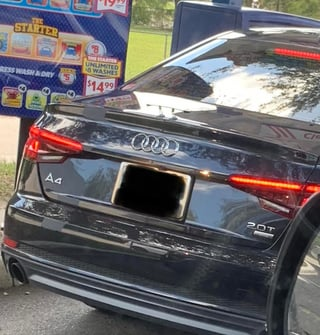

In [8]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [9]:
# Display the number of fake/real labels
print(image_df["label"].value_counts())

label
1    150
0     75
Name: count, dtype: int64


# Balance

Balance the pre-processed Fakeddit subset.

In [10]:
# Split by label
fake_df = image_df[image_df["label"] == 0]
real_df = image_df[image_df["label"] == 1]

# Use the minority class size as target size per class
n_per_class = min(len(fake_df), len(real_df))
print(f"Using n_per_class = {n_per_class} for each class")

# Build balanced subset: sampled fakes + sampled reals
balanced_df = pd.concat([
    fake_df.sample(n=n_per_class, random_state=42),
    real_df.sample(n=n_per_class, random_state=42)
])

# Shuffle rows
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced counts:")
print(balanced_df["label"].value_counts())
print("Balanced shape:", balanced_df.shape)

balanced_df.head()

Using n_per_class = 75 for each class
Balanced counts:
label
0    75
1    75
Name: count, dtype: int64
Balanced shape: (150, 5)


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,0,https://preview.redd.it/m0yhjb563ek21.jpg?widt...,"yoda is sitting in a chair with the caption, ""..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,0,https://external-preview.redd.it/N5dbbbo3nx7uw...,a woman is standing in front of microphones
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,1,https://preview.redd.it/knd5hhyozny21.jpg?widt...,a room with purple walls and green furniture
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,1,https://preview.redd.it/70y4l9yhcsc31.jpg?widt...,a leaf on the sidewalk
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,1,https://preview.redd.it/0ksailoiupe31.jpg?widt...,a baseball card with a picture of a man on it


# Save

Save the balanced subset for use in final comparisons.

In [11]:
# Save the final CSV
output_file = "fakeddit_balanced_subset.csv"
balanced_df.to_csv(output_file, index=False)

# Download the CSV
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>